# Revision: Scene setting
- Global scene setting: Same to CuRobo, Moveit, etc.

#### 1. Initialize environment

In [1]:
from ri_motion_v5_package.init_scripts.init_ipython_setup import *
from ri_motion_v5_package.init_scripts.init_qt import *
from ri_motion_v5_package.mujoco_sim import *
from ri_motion_v5_package.kinematics import *
from ri_motion_v5_package.utility import *
from ri_motion_v5_package.qt import *

from package.panda_env import * 

from PyQt5.QtWidgets import QApplication
app = QApplication(sys.argv)

Basic packages initialized.
 import numpy as np
 import matplotlib.pyplot as plt
 import scipy as sp
 from PIL import Image
[ipython] settings (retina, inline, qt) initialized.
[numpy] settings initialized.
[matplotlib] settings initialized.
[qt] package initialized.


In [2]:
xml_path = merge_mjcfs(
    included_mjcf_files = [
        '../../asset/floor/floor_white_gray.xml',
        './asset/panda_inspire/panda_inspire_site_added.xml',
        './asset/cabinet/cabinet_half_closed.xml',
        './asset/object/cylinder.xml',
    ],
    output_xml_path = 'xml/panda_cabinet_scene.xml',
)
env = MuJoCoParser(rel_xml_path=xml_path,verbose=True)

[merge_mjcfs] Merging [4] MJCF files:
  - [0] [../../asset/floor/floor_white_gray.xml]
  - [1] [./asset/panda_inspire/panda_inspire_site_added.xml]
  - [2] [./asset/cabinet/cabinet_half_closed.xml]
  - [3] [./asset/object/cylinder.xml]
[merge_mjcfs] Saved merged XML to:[xml/panda_cabinet_scene.xml]

-----------------------------------------------------------------------------
name:[scene] dt:[0.002] HZ:[500]
 n_q:[26] n_v:[25] n_u:[7]
 integrator:[IMPLICITFAST]

Body information. n_body:[28]
 [0/28] [world] parent:[world] mass:[0.00]kg
 [1/28] [panda_base] parent:[world] mass:[0.00]kg
 [2/28] [panda_link_0] parent:[panda_base] mass:[4.00]kg
 [3/28] [panda_link_1] parent:[panda_link_0] mass:[3.00]kg
 [4/28] [panda_link_2] parent:[panda_link_1] mass:[3.00]kg
 [5/28] [panda_link_3] parent:[panda_link_2] mass:[2.00]kg
 [6/28] [panda_link_4] parent:[panda_link_3] mass:[2.00]kg
 [7/28] [panda_link_5] parent:[panda_link_4] mass:[2.00]kg
 [8/28] [panda_link_6] parent:[panda_link_5] mass:[1.50]

#### 2. Intialize environment and generate smooth trajectory

In [3]:
# Configurations
panda_joints          = get_panda_joint_names() # check
inspire_joints        = get_inspire_joint_names() # check
inspire_active_joints = env.get_active_among_joints(inspire_joints)
p_cylinder_offset0    = get_p_offset_palm_to_cylinder()
qactive_inspire0      = get_qactive_inspire() # check
q_inspire0            = get_q_inspire(env) # check
q_pandas              = get_q_pandas_cabinet() # check

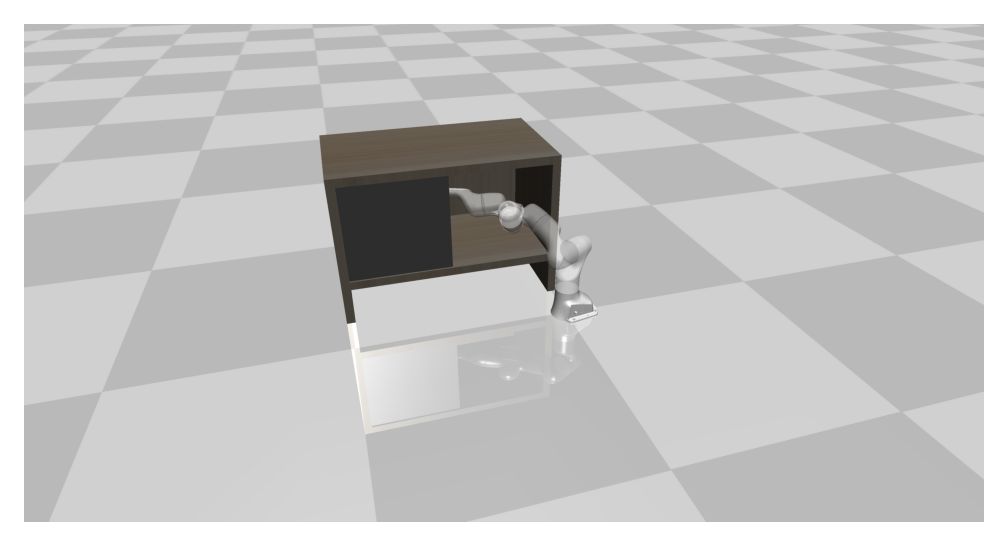

Done.


In [7]:
# set panda env 
width,height,x_offset,y_offset = 0.8,0.8,0.1,0.15
set_panda_cabinet_env(
    env,panda_joints,inspire_joints,q_pandas['init'],q_inspire0,
    width,height,x_offset,y_offset, # initialize_viewer=False,
)

# Loop
while env.is_viewer_alive():
    env.forward(q=q_pandas['final'],joint_names=panda_joints)
    T_palm = get_T_palm_panda_inspire(env)
    T_cylinder = view_in_world(T=p2t(p_cylinder_offset0),T_wl=T_palm)
    env.set_T('body_cylinder','base_body',T_cylinder)

    # Get contact information
    contact_info = env.get_contact_info()
    
    # Render
    env.viewer_text_overlay('#contact','[%d]'%(contact_info['n_contact']))
    env.viewer_text_overlay('min_contact_dist','[%.3f]'%(contact_info['min_contact_dist']))
    env.plot_global_coordinate_axes()
    env.plot_contact_info()
    env.render()
    app.processEvents()

# Final image show
imshow(env.final_rgb_img)

# Close
env.close_viewer()
print("Done.")